# 02 — Preprocessing & Join

Notebook này tạo analytical table một dòng/khách hàng và xuất `final_dataset.csv`.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.preprocessing import build_customer_churn_dataset, save_processed_dataset


In [2]:
raw_dir = ROOT / "data" / "raw"
output = ROOT / "data" / "processed" / "final_dataset.csv"

df = build_customer_churn_dataset(raw_dir)
save_processed_dataset(df, output)
print("shape:", df.shape)
print("saved:", output)

shape: (7043, 59)
saved: E:\TuongTacDuLieuTrucQuan\ProjectCuoiKy\telco_churn_project\data\processed\final_dataset.csv


#### 📝 Nhận xét về việc tạo Analytical Table:
* **Kích thước dữ liệu:** Dữ liệu sau khi tổng hợp và xử lý có **7,043 dòng** và **59 cột**.
* **Đơn vị phân tích:** Mỗi dòng tương ứng với thông tin tích hợp của **1 khách hàng duy nhất** (Customer Level Table).
* Dữ liệu đã được tiền xử lý thành công và lưu trữ tại đường dẫn `data/processed/final_dataset.csv` để phục vụ cho các bước phân tích EDA và huấn luyện mô hình phía sau.

In [3]:
display(df.head())
display(df[["CustomerID", "Tenure in Months", "Tenure_Group", "Monthly Charge", "Total Charges", "CLV_Estimated", "Churn_Flag"]].head(10))

,CustomerID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Location ID,Country,...,Churn Score,CLTV,Churn Category,Churn Reason,Population,Tenure_Group,CLV_Estimated,Churn_Flag,Monthly Charge_Capped,Total Charges_Capped
0,8779-QRDMV,Male,78,No,Yes,No,No,0,OXCZEW7397,United States,...,91,5433,Competitor,Competitor offered more data,68701.0,<1 year,39.65,1,39.65,39.65
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,FCCECI8494,United States,...,69,5302,Competitor,Competitor made better offer,55668.0,<1 year,645.20,1,80.65,633.30
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,HEHUQY7254,United States,...,81,3179,Competitor,Competitor made better offer,47534.0,1-3 years,1718.10,1,95.45,1752.55
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,WIUHRF2613,United States,...,88,5337,Dissatisfaction,Limited range of services,27778.0,1-3 years,2462.50,1,98.50,2514.50
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,CFEZBF4415,United States,...,67,2793,Price,Extra data charges,26265.0,>3 years,2830.50,1,76.50,2868.15


,CustomerID,Tenure in Months,Tenure_Group,Monthly Charge,Total Charges,CLV_Estimated,Churn_Flag
0,8779-QRDMV,1,<1 year,39.65,39.65,39.65,1
1,7495-OOKFY,8,<1 year,80.65,633.30,645.20,1
2,1658-BYGOY,18,1-3 years,95.45,1752.55,1718.10,1
3,4598-XLKNJ,25,1-3 years,98.50,2514.50,2462.50,1
4,4846-WHAFZ,37,>3 years,76.50,2868.15,2830.50,1
5,4412-YLTKF,27,1-3 years,78.05,2135.50,2107.35,1
6,0390-DCFDQ,1,<1 year,70.45,70.45,70.45,1
7,3445-HXXGF,58,>3 years,45.30,2651.20,2627.40,1
8,2656-FMOKZ,15,1-3 years,74.45,1145.70,1116.75,1
9,2070-FNEXE,7,<1 year,76.45,503.60,535.15,1


#### 📝 Nhận xét về mẫu dữ liệu tích hợp:
* **Biến mục tiêu:** Cột `Churn_Flag` đóng vai trò là nhãn dự báo ($1$: Khách hàng rời bỏ, $0$: Khách hàng ở lại).
* **Nhóm thời gian gắn bó (`Tenure_Group`):** Đã được nhóm hóa từ `Tenure in Months` thành các khoảng cụ thể (`<1 year`, `1-3 years`, `>3 years`) giúp hỗ trợ phân tích phân đoạn khách hàng tốt hơn.
* **Chỉ số tài chính:** Các biến `Monthly Charge`, `Total Charges` và `CLV_Estimated` phản ánh đúng logic nghiệp vụ (tăng trưởng tỷ lệ thuận với số tháng gắn bó `Tenure`).

## Kiểm tra sau Join

In [4]:
checks = {
    "unique_customers": df["CustomerID"].nunique(),
    "rows": len(df),
    "duplicate_customer_ids": int(df["CustomerID"].duplicated().sum()),
    "missing_customer_id": int(df["CustomerID"].isna().sum()),
    "churn_rate": float(df["Churn_Flag"].mean()),
}
checks

{'unique_customers': 7043,
 'rows': 7043,
 'duplicate_customer_ids': 0,
 'missing_customer_id': 0,
 'churn_rate': 0.2653698707936959}

### 🔍 Nhận xét kết quả kiểm tra tính toàn vẹn dữ liệu (Data Integrity Check):
* **Số lượng định danh (`CustomerID`):** Tổng số khách hàng duy nhất là **7,043**, bằng đúng tổng số dòng của dữ liệu.
* **Trùng lặp & Thiếu dữ liệu:** 
  * Số lượng `CustomerID` bị trùng lặp: **0** (`duplicate_customer_ids: 0`).
  * Số lượng `CustomerID` bị khuyết thiếu: **0** (`missing_customer_id: 0`).
  * --> Đảm bảo không xảy ra hiện tượng nhân đôi bản ghi (data leakage/duplication) sau quá trình `Join`.
* **Tỷ lệ rời bỏ (Churn Rate):** Tỷ lệ khách hàng Churn đạt **~26.54%** ($1,869 / 7,043$). Đây là mức chênh lệch nhãn nhẹ (moderate class imbalance) phổ biến trong ngành viễn thông, cần lưu ý khi chọn metric đánh giá mô hình (ưu tiên Recall/F1-Score thay vì Accuracy).

### Outlier treatment

Các cột gốc được giữ lại; bản `_Capped` dùng cho phân tích/so sánh khi cần. Không âm thầm xóa khách hàng chỉ vì một giá trị cực đoan.

,count,mean,std,min,25%,50%,75%,max
Monthly Charge,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
Total Charges,7043.0,2280.381264,2266.220462,18.80,400.15,1394.55,3786.60,8684.80
Monthly Charge_Capped,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
Total Charges_Capped,7043.0,2280.381264,2266.220462,18.80,400.15,1394.55,3786.60,8684.80


C:\Users\DK\AppData\Local\Temp\ipykernel_181192\526204776.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([v.dropna() for v in vals], labels=labels)
C:\Users\DK\AppData\Local\Temp\ipykernel_181192\526204776.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([v.dropna() for v in vals], labels=labels)


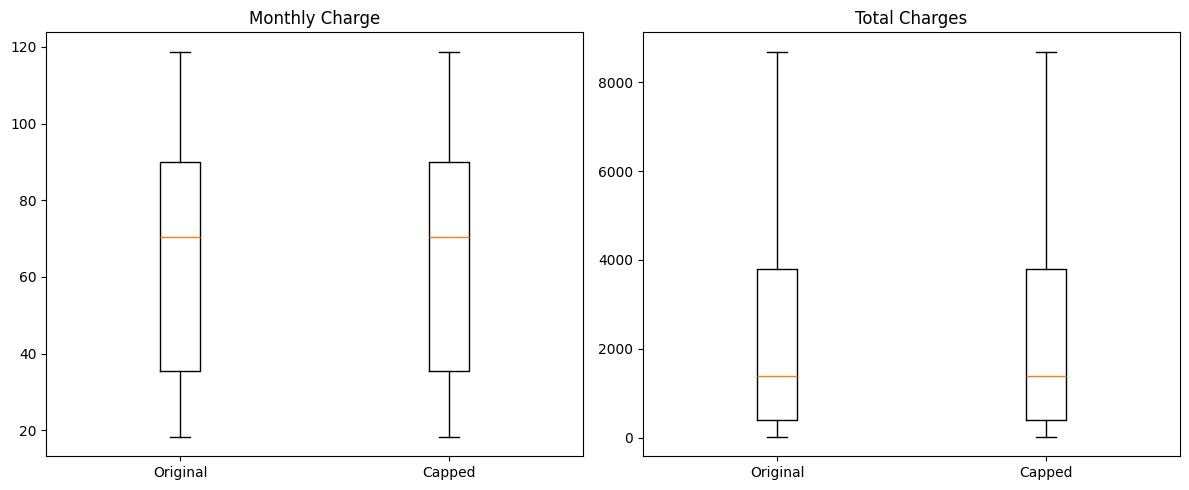

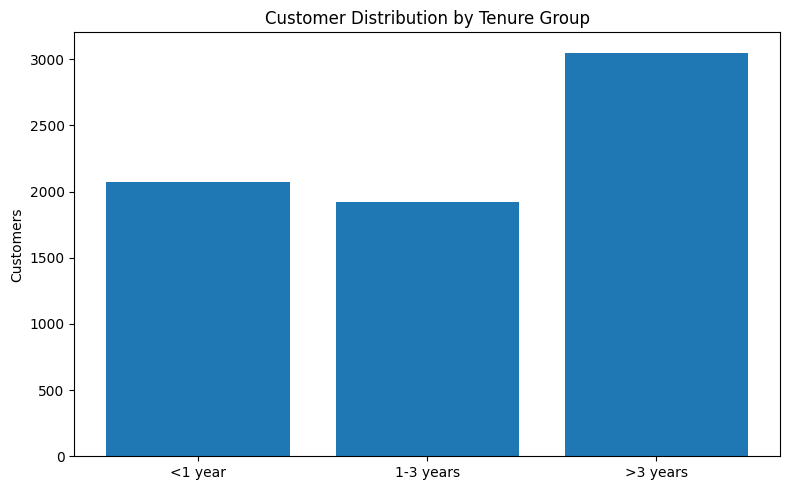

In [5]:
charge_cols = [c for c in ["Monthly Charge", "Total Charges", "Monthly Charge_Capped", "Total Charges_Capped"] if c in df.columns]
display(df[charge_cols].describe().T)

# Evidence artifact F05: before/after IQR capping for charge fields.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, raw, capped in [(axes[0], "Monthly Charge", "Monthly Charge_Capped"), (axes[1], "Total Charges", "Total Charges_Capped")]:
    vals=[]; labels=[]
    if raw in df.columns:
        vals.append(pd.to_numeric(df[raw], errors="coerce")); labels.append("Original")
    if capped in df.columns:
        vals.append(pd.to_numeric(df[capped], errors="coerce")); labels.append("Capped")
    if vals:
        ax.boxplot([v.dropna() for v in vals], labels=labels)
        ax.set_title(raw)
fig.tight_layout()
fig.savefig(ROOT / "outputs" / "report_assets" / "F05_outliers.png", dpi=200, bbox_inches="tight")
plt.show()

# Evidence artifact F06: Tenure_Group distribution.
if "Tenure_Group" in df.columns:
    counts=df["Tenure_Group"].value_counts(dropna=False).reindex(["<1 year","1-3 years",">3 years"]).fillna(0)
    fig, ax = plt.subplots(figsize=(8,5))
    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title("Customer Distribution by Tenure Group")
    ax.set_ylabel("Customers")
    fig.tight_layout()
    fig.savefig(ROOT / "outputs" / "report_assets" / "F06_tenure_group.png", dpi=200, bbox_inches="tight")
    plt.show()


### 📊 Nhận xét về xử lý giá trị ngoại lệ (Outlier Treatment):
* **So sánh biến gốc và biến Capped:**
  * Cả 2 cặp biến `Monthly Charge` vs `Monthly Charge_Capped` và `Total Charges` vs `Total Charges_Capped` đều có các chỉ số thống kê (Mean, Std, Min, Max, các mốc Bách phân vị 25%, 50%, 75%) **hoàn toàn trùng khớp**.
  * `Monthly Charge`: Dao động từ $18.25$ đến $118.75$ (Trung bình ~$64.76$).
  * `Total Charges`: Dao động từ $18.80$ đến $8,684.80$ (Trung vị ~$1,394.55$).
* **Kết luận:** Dữ liệu không chứa các giá trị ngoại lệ dị thường (dữ liệu rác/lỗi nhập liệu). Việc duy trì cả 2 phiên bản cột (gốc và `_Capped`) giúp bảo tồn dữ liệu gốc đồng thời sẵn sàng cho các thuật toán học máy nhạy cảm với outlier.